## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [0]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

### Find no.of samples are there in training and test datasets

In [17]:
x_train.shape

(60000, 28, 28)

In [18]:
x_test.shape

(10000, 28, 28)

### Find dimensions of an image in the dataset 

Training data set is 60000 samples with 28x28 size images
Test data set is 10000 samples with 28x28 size images

Since the dataset 3rd dimension is 1, it is not a color data

x_train and x_test parts contain greyscale RGB codes (from 0 to 255) while y_train and y_test parts contains labels from 0 to 9 which represents which number they actually are


### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
import tensorflow as tf
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
#Normalize after converting to float since we are using divide by 255 to normalize
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
#Convert in to 1D vector to match input dimensions of conv2D layers
#Reshape data from 2D to 1D -> 28x28 to 784
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

### Import the necessary layers from keras to build the model

In [0]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
from keras import regularizers
from keras import optimizers


import keras
import keras.utils
from keras import utils as np_utils

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [0]:
#Initialize Sequential model
model = Sequential()

#Normalize the data
model.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model.add(Flatten()) # Flattening the 2D arrays for fully connected layers
model.add(Dense(128, activation="relu"))
model.add(Dense(10,activation="softmax"))

In [24]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_5 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 24, 24, 32)        9248      
_________________________________________________________________
flatten_3 (Flatten)          (None, 18432)             0         
_________________________________________________________________
dense_5 (Dense)              (None, 128)               2359424   
_________________________________________________________________
dense_6 (Dense)              (None, 10)                1290      
Total params: 2,370,282
Trainable params: 2,370,282
Non-trainable params: 0
_________________________________________________________________


In [0]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [26]:
# simple early stopping
callbacks = [
    keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor='val_loss',
        # "no longer improving" being defined as "no better than 1e-2 less"
        min_delta=1e-2,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=5,
        mode='min',
        verbose=1)
]

model.fit(x_train, y_train,
          epochs=10,
          batch_size=64,
          callbacks=callbacks
          )

Epoch 1/10
60000/60000 [==============================] - 6s 107us/step - loss: 0.3969 - acc: 0.8575
Epoch 2/10
 1664/60000 [..............................] - ETA: 5s - loss: 0.2795 - acc: 0.8996

/usr/local/lib/python3.6/dist-packages/keras/callbacks.py:569: RuntimeWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc
  (self.monitor, ','.join(list(logs.keys()))), RuntimeWarning


60000/60000 [==============================] - 6s 98us/step - loss: 0.2513 - acc: 0.9082
Epoch 3/10
60000/60000 [==============================] - 6s 98us/step - loss: 0.1875 - acc: 0.9304
Epoch 4/10
60000/60000 [==============================] - 6s 97us/step - loss: 0.1396 - acc: 0.9475
Epoch 5/10
60000/60000 [==============================] - 6s 96us/step - loss: 0.0984 - acc: 0.9635
Epoch 6/10
60000/60000 [==============================] - 6s 96us/step - loss: 0.0681 - acc: 0.9750
Epoch 7/10
60000/60000 [==============================] - 6s 95us/step - loss: 0.0481 - acc: 0.9825
Epoch 8/10
60000/60000 [==============================] - 6s 95us/step - loss: 0.0350 - acc: 0.9873
Epoch 9/10
60000/60000 [==============================] - 6s 95us/step - loss: 0.0268 - acc: 0.9907
Epoch 10/10
60000/60000 [==============================] - 6s 96us/step - loss: 0.0239 - acc: 0.9918


In [27]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_5 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 24, 24, 32)        9248      
_________________________________________________________________
flatten_3 (Flatten)          (None, 18432)             0         
_________________________________________________________________
dense_5 (Dense)              (None, 128)               2359424   
_________________________________________________________________
dense_6 (Dense)              (None, 10)                1290      
Total params: 2,370,282
Trainable params: 2,370,282
Non-trainable params: 0
_________________________________________________________________


In [28]:
model.evaluate(x_test, y_test)

10000/10000 [==============================] - 1s 56us/step


[0.43837445956915616, 0.9136]

### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [29]:
#Initialize Sequential model
model1 = Sequential()

#Normalize the data
model1.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model1.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model1.add(keras.layers.MaxPool2D(pool_size=(2,2)))
model1.add(keras.layers.Dropout(0.25))

model1.add(Flatten()) # Flattening the 2D arrays for fully connected layers

model1.add(Dense(128, activation="relu"))
model1.add(Dense(10,activation="softmax"))
model1.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_7 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_8 (Conv2D)            (None, 24, 24, 32)        9248      
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 12, 12, 32)        0         
_________________________________________________________________
dropout_2 (Dropout)          (None, 12, 12, 32)        0         
_________________________________________________________________
flatten_4 (Flatten)          (None, 4608)              0         
_________________________________________________________________
dense_7 (Dense)              (None, 128)               589952    
_________________________________________________________________
dense_8 (Dense)              (None, 10)                1290      
Total para

In [30]:
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# simple early stopping
callbacks1= [
    keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor='val_loss',
        # "no longer improving" being defined as "no better than 1e-2 less"
        min_delta=1e-2,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=5,
        mode='min',
        verbose=1)
]

model1.fit(x_train, y_train,
          epochs=10,
          batch_size=64,
          callbacks=callbacks1
          )

Epoch 1/10
60000/60000 [==============================] - 5s 85us/step - loss: 0.4211 - acc: 0.8491
Epoch 2/10
 2112/60000 [>.............................] - ETA: 4s - loss: 0.2768 - acc: 0.9010

/usr/local/lib/python3.6/dist-packages/keras/callbacks.py:569: RuntimeWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc
  (self.monitor, ','.join(list(logs.keys()))), RuntimeWarning


60000/60000 [==============================] - 5s 76us/step - loss: 0.2743 - acc: 0.9004
Epoch 3/10
60000/60000 [==============================] - 5s 76us/step - loss: 0.2258 - acc: 0.9167
Epoch 4/10
60000/60000 [==============================] - 5s 76us/step - loss: 0.1932 - acc: 0.9288
Epoch 5/10
60000/60000 [==============================] - 5s 76us/step - loss: 0.1677 - acc: 0.9373
Epoch 6/10
60000/60000 [==============================] - 5s 76us/step - loss: 0.1448 - acc: 0.9462
Epoch 7/10
60000/60000 [==============================] - 5s 76us/step - loss: 0.1256 - acc: 0.9523
Epoch 8/10
60000/60000 [==============================] - 5s 76us/step - loss: 0.1069 - acc: 0.9604
Epoch 9/10
60000/60000 [==============================] - 5s 76us/step - loss: 0.0908 - acc: 0.9657
Epoch 10/10
60000/60000 [==============================] - 5s 76us/step - loss: 0.0812 - acc: 0.9696


In [31]:
model1.evaluate(x_test, y_test)

10000/10000 [==============================] - 1s 58us/step


[0.24731409967243673, 0.9217]

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [32]:
#Initialize Sequential model
model2 = Sequential()

#Normalize the data
model2.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model2.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model2.add(keras.layers.MaxPool2D(pool_size=(2,2)))
model2.add(keras.layers.Dropout(0.25))

model2.add(Flatten()) # Flattening the 2D arrays for fully connected layers

model2.add(Dense(128, activation="relu"))
model2.add(Dense(10,activation="softmax"))
model2.summary()
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# simple early stopping
callbacks2 = [
    keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor='val_loss',
        # "no longer improving" being defined as "no better than 1e-2 less"
        min_delta=1e-2,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=5,
        mode='min',
        verbose=1)
]

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_9 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_10 (Conv2D)           (None, 24, 24, 32)        9248      
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 12, 12, 32)        0         
_________________________________________________________________
dropout_3 (Dropout)          (None, 12, 12, 32)        0         
_________________________________________________________________
flatten_5 (Flatten)          (None, 4608)              0         
_________________________________________________________________
dense_9 (Dense)              (None, 128)               589952    
_________________________________________________________________
dense_10 (Dense)             (None, 10)                1290      
Total para

In [0]:
train_gen =  keras.preprocessing.image.ImageDataGenerator(rotation_range=4, 
                               width_shift_range=0.1, 
                               shear_range=0.3, 
                               horizontal_flip=True,
                               height_shift_range=0.1, 
                               zoom_range=0.08 )

test_gen = keras.preprocessing.image.ImageDataGenerator(rotation_range=4, 
                               width_shift_range=0.1, 
                               shear_range=0.3, 
                               horizontal_flip=True,
                               height_shift_range=0.1, 
                               zoom_range=0.08 )

training_set= train_gen.flow(x_train, y_train, batch_size=64)
test_set= train_gen.flow(x_test, y_test, batch_size=64)

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

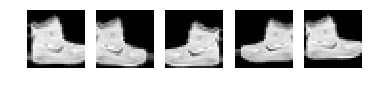

In [34]:
from matplotlib import pyplot as plt
gen = train_gen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [35]:
model2.fit_generator(training_set, 
                         steps_per_epoch=60000//64, 
                         validation_data= test_set, 
                         validation_steps=10000//64, 
                         epochs=10,
                         callbacks=callbacks2)


Epoch 1/10
937/937 [==============================] - 18s 20ms/step - loss: 0.6500 - acc: 0.7576 - val_loss: 0.5064 - val_acc: 0.8059
Epoch 2/10
937/937 [==============================] - 26s 28ms/step - loss: 0.4699 - acc: 0.8227 - val_loss: 0.4427 - val_acc: 0.8327
Epoch 3/10
937/937 [==============================] - 18s 19ms/step - loss: 0.4203 - acc: 0.8412 - val_loss: 0.3985 - val_acc: 0.8538
Epoch 4/10
937/937 [==============================] - 18s 19ms/step - loss: 0.3837 - acc: 0.8571 - val_loss: 0.3693 - val_acc: 0.8653
Epoch 5/10
937/937 [==============================] - 18s 19ms/step - loss: 0.3613 - acc: 0.8642 - val_loss: 0.3640 - val_acc: 0.8650
Epoch 6/10
937/937 [==============================] - 18s 19ms/step - loss: 0.3398 - acc: 0.8731 - val_loss: 0.3369 - val_acc: 0.8721
Epoch 7/10
937/937 [==============================] - 18s 19ms/step - loss: 0.3269 - acc: 0.8782 - val_loss: 0.3258 - val_acc: 0.8806
Epoch 8/10
937/937 [==============================] - 18s 19ms

###  Report the final train and validation accuracy

In [36]:
model2.evaluate(x_train, y_train)

60000/60000 [==============================] - 3s 54us/step


[0.23308508400817712, 0.9114833333333333]

In [37]:
model2.evaluate(x_test, y_test)

10000/10000 [==============================] - 1s 54us/step


[0.26028772443532944, 0.9046]

## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [0]:
from keras.datasets import cifar10

### **Load CIFAR10 dataset**

In [39]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170500096/170498071 [==============================] - 9s 0us/step


In [40]:
x_train.shape

(50000, 32, 32, 3)

In [41]:
x_test.shape

(10000, 32, 32, 3)

In [0]:
#Normalize after converting to float since we are using divide by 255 to normalize
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

In [0]:
input_shape = x_train.shape[1:]

In [0]:

# Convert class vectors to binary class matrices.
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
train_gen =  keras.preprocessing.image.ImageDataGenerator(rotation_range=4, 
                               width_shift_range=0.05, 
                               shear_range=0.5, 
                               horizontal_flip=True,
                               height_shift_range=0.08, 
                               zoom_range=0.08 )

test_gen = keras.preprocessing.image.ImageDataGenerator(rotation_range=4, 
                               width_shift_range=0.05, 
                               shear_range=0.5, 
                               horizontal_flip=True,
                               height_shift_range=0.08, 
                               zoom_range=0.08 )

training_set= train_gen.flow(x_train, y_train, batch_size=64)
test_set= train_gen.flow(x_test, y_test, batch_size=64)

### **Prepare/fit the generator.**

In [46]:
#Initialize Sequential model
model3 = Sequential()

#Normalize the data
model3.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu", padding='same'))
model3.add(Conv2D(64, kernel_size=(3,3), input_shape=input_shape, activation="relu", padding='same'))
model3.add(keras.layers.MaxPool2D(pool_size=(2,2)))
model3.add(keras.layers.Dropout(0.25))

model3.add(Flatten()) # Flattening the 2D arrays for fully connected layers

model3.add(Dense(512, activation="relu"))
model3.add(Dense(10,activation="softmax"))
model3.summary()
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# simple early stopping
callbacks3 = [
    keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor='val_loss',
        # "no longer improving" being defined as "no better than 1e-2 less"
        min_delta=1e-2,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=5,
        mode='min',
        verbose=1)
]

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_11 (Conv2D)           (None, 32, 32, 32)        896       
_________________________________________________________________
conv2d_12 (Conv2D)           (None, 32, 32, 64)        18496     
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 16, 16, 64)        0         
_________________________________________________________________
dropout_4 (Dropout)          (None, 16, 16, 64)        0         
_________________________________________________________________
flatten_6 (Flatten)          (None, 16384)             0         
_________________________________________________________________
dense_11 (Dense)             (None, 512)               8389120   
_________________________________________________________________
dense_12 (Dense)             (None, 10)                5130      
Total para

In [47]:
model3.fit_generator(training_set, 
                         steps_per_epoch=50000//32, 
                         validation_data= test_set, 
                         validation_steps=50000//32, 
                         epochs=10,
                         callbacks=callbacks3)


Epoch 1/10
1562/1562 [==============================] - 84s 53ms/step - loss: 1.2713 - acc: 0.5476 - val_loss: 1.0469 - val_acc: 0.6308
Epoch 2/10
1562/1562 [==============================] - 82s 53ms/step - loss: 0.9716 - acc: 0.6574 - val_loss: 0.9572 - val_acc: 0.6627
Epoch 3/10
1562/1562 [==============================] - 83s 53ms/step - loss: 0.8506 - acc: 0.6989 - val_loss: 0.8543 - val_acc: 0.7013
Epoch 4/10
1562/1562 [==============================] - 83s 53ms/step - loss: 0.7715 - acc: 0.7286 - val_loss: 0.8039 - val_acc: 0.7197
Epoch 5/10
1562/1562 [==============================] - 83s 53ms/step - loss: 0.7103 - acc: 0.7507 - val_loss: 0.7849 - val_acc: 0.7284
Epoch 6/10
1562/1562 [==============================] - 83s 53ms/step - loss: 0.6685 - acc: 0.7651 - val_loss: 0.7623 - val_acc: 0.7391
Epoch 7/10
1562/1562 [==============================] - 83s 53ms/step - loss: 0.6315 - acc: 0.7777 - val_loss: 0.7767 - val_acc: 0.7341
Epoch 8/10
1562/1562 [==========================

In [49]:
model3.evaluate(x_train, y_train)

50000/50000 [==============================] - 4s 87us/step


[0.40267963981151583, 0.85994]

In [50]:
model3.evaluate(x_test, y_test)

10000/10000 [==============================] - 1s 89us/step


[0.7699687702178956, 0.7599]

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

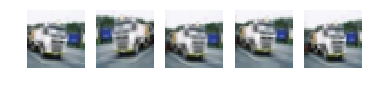

In [51]:
from matplotlib import pyplot as plt
gen = train_gen.flow(x_train[1000:1001], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze())
    plt.plot()
plt.show()